Text(0.5, 1.0, 'Study Region: Northern Bay of Bengal (20$^\\circ$N to 23$^\\circ$N, 87$^\\circ$E to 91$^\\circ$E)')

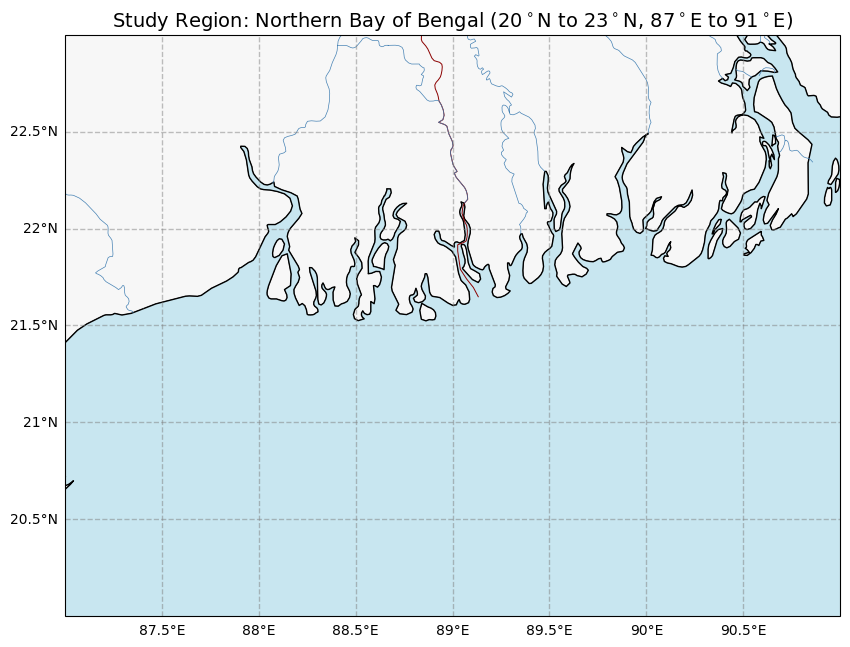

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# Import the formatters directly from cartopy.mpl.ticker
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter 
import cartopy.feature as cfeature

# 1. Define the Study Region Boundaries
minimum_longitude = 87
maximum_longitude = 91
minimum_latitude = 20
maximum_latitude = 23

# 2. Setup the Figure and Geographic Projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# 3. Set the Extent (Zoom) to your study region
ax.set_extent([minimum_longitude, maximum_longitude, minimum_latitude, maximum_latitude], crs=ccrs.PlateCarree())

# 4. Add Real-World Map Features with Colors
# Using a lighter gray for land and light blue for ocean
ax.add_feature(cfeature.LAND, facecolor='#f7f7f7', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='#c8e6f0')
ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='darkred', linewidth=0.7)
ax.add_feature(cfeature.RIVERS, edgecolor='#4682b4', linewidth=0.5)

# 5. Add Gridlines for Research Paper Quality
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False    # Remove labels from the top edge
gl.right_labels = False  # Remove labels from the right edge

# **CORRECTION APPLIED HERE:** Use the imported formatters
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

# 6. Add Axis Labels and Title
ax.set_xlabel('Longitude ($^\circ$E)', fontsize=12)
ax.set_ylabel('Latitude ($^\circ$N)', fontsize=12)
ax.set_title(f'Study Region: Northern Bay of Bengal ({minimum_latitude}$^\circ$N to {maximum_latitude}$^\circ$N, {minimum_longitude}$^\circ$E to {maximum_longitude}$^\circ$E)', fontsize=14)

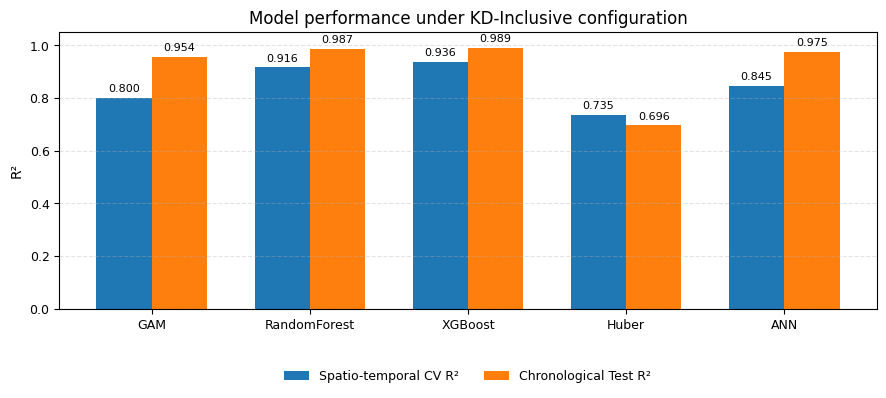

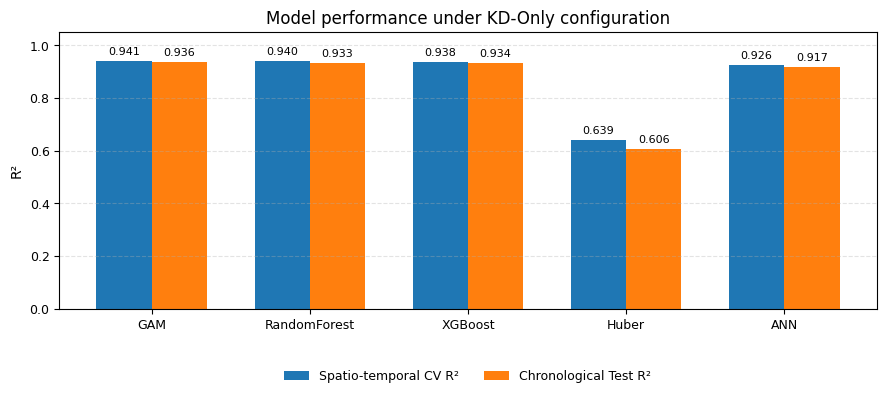

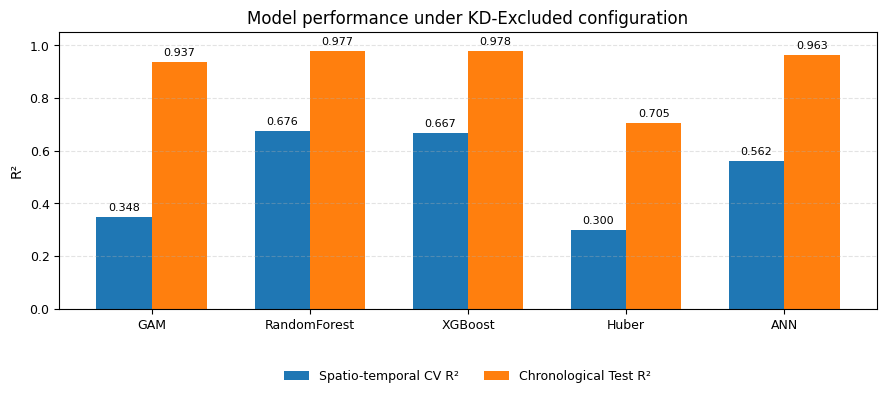

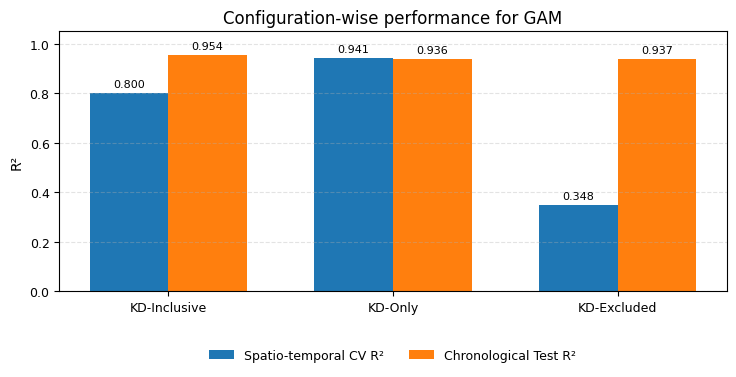

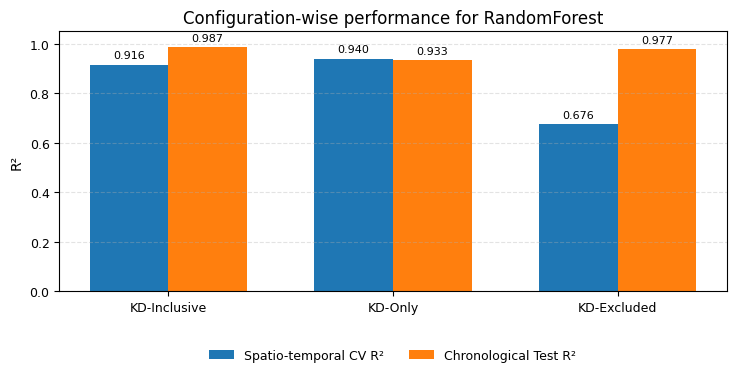

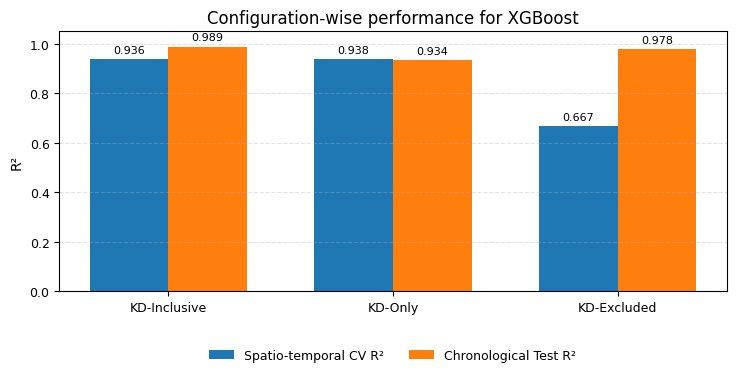

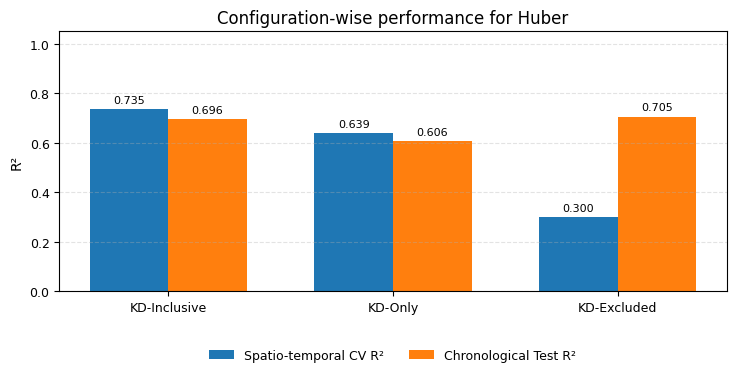

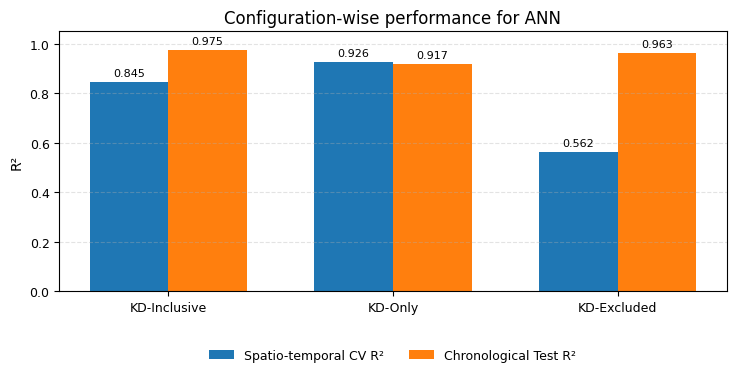

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------------------
# OUTPUT DIRECTORY
# ---------------------------
out_dir = "figures_paper"
os.makedirs(out_dir, exist_ok=True)

# ---------------------------
# DATA: replace these with your final numbers if needed
# Rows = models; columns = metrics for each configuration
# ---------------------------
models = ["GAM", "RandomForest", "XGBoost", "Huber", "ANN"]
configs = ["KD-Inclusive", "KD-Only", "KD-Excluded"]

data = {
    "Model": models,
    # KD-Inclusive
    "KD-Inclusive_CV": [0.7996, 0.9159, 0.9364, 0.7351, 0.8451],
    "KD-Inclusive_Test": [0.9541, 0.9873, 0.9886, 0.6957, 0.9747],
    # KD-Only
    "KD-Only_CV": [0.9409, 0.9402, 0.9380, 0.6394, 0.9259],
    "KD-Only_Test": [0.9364, 0.9328, 0.9343, 0.6058, 0.9174],
    # KD-Excluded
    "KD-Excluded_CV": [0.3485, 0.6765, 0.6675, 0.2996, 0.5617],
    "KD-Excluded_Test": [0.9368, 0.9774, 0.9784, 0.7051, 0.9628],
}

df = pd.DataFrame(data)

# ---------------------------
# Utility: annotate bars
# ---------------------------
def annotate_bars(ax, rects, fmt="{:.3f}", y_offset=3):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(fmt.format(h),
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, y_offset),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

# ---------------------------
# Global plot style tweaks (keeps default color cycle)
# ---------------------------
plt.rcParams.update({
    "figure.dpi": 100,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# ---------------------------
# PART A: 3 plots - one plot per configuration
# (X-axis: Models; bars: CV R² and Test R²)
# ---------------------------
for cfg in configs:
    cv_col = f"{cfg}_CV"
    test_col = f"{cfg}_Test"

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 4.2))
    rects1 = ax.bar(x - width/2, df[cv_col], width, label="Spatio-temporal CV R²")
    rects2 = ax.bar(x + width/2, df[test_col], width, label="Chronological Test R²")

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=0)
    ax.set_ylabel("R²")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Model performance under {cfg} configuration")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    annotate_bars(ax, rects1, fmt="{:.3f}")
    annotate_bars(ax, rects2, fmt="{:.3f}")

    # Legend BELOW plot, single row
    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5, -0.18),
              ncol=2,
              frameon=False)

    # Tight layout with extra padding to accommodate legend
    plt.tight_layout(pad=1.2)
    plt.show()

# ---------------------------
# PART B: 5 plots - one plot per model family
# (X-axis: Configurations; bars: CV R² and Test R²)
# ---------------------------
for i, model in enumerate(models):
    cv_vals = [df[f"{cfg}_CV"][i] for cfg in configs]
    test_vals = [df[f"{cfg}_Test"][i] for cfg in configs]

    x = np.arange(len(configs))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7.5, 4))
    rects1 = ax.bar(x - width/2, cv_vals, width, label="Spatio-temporal CV R²")
    rects2 = ax.bar(x + width/2, test_vals, width, label="Chronological Test R²")

    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.set_ylabel("R²")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Configuration-wise performance for {model}")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    annotate_bars(ax, rects1, fmt="{:.3f}")
    annotate_bars(ax, rects2, fmt="{:.3f}")

    # Legend BELOW plot, single row
    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5, -0.18),
              ncol=2,
              frameon=False)

    plt.tight_layout(pad=1.2)
    plt.show()